In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [ ]:
df=pd.read_csv("Gold_Price.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2021-01-01,3706.97,168.10,39.33,21.67,1.2047
1,2021-01-02,3715.81,169.67,38.09,21.57,1.1953
2,2021-01-03,3701.74,169.69,36.67,21.21,1.1983
3,2021-01-04,3703.99,168.57,36.93,21.58,1.1885
4,2021-01-05,3719.28,169.36,36.45,21.17,1.1976


In [ ]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
995,2023-09-23,4072.97,156.55,61.69,13.82,1.1068
996,2023-09-24,4082.70,155.65,61.77,13.85,1.1107
997,2023-09-25,4088.30,154.08,62.46,14.00,1.1204
998,2023-09-26,4087.48,154.84,63.76,14.59,1.1162
999,2023-09-27,4092.93,154.10,63.83,15.18,1.1133


In [ ]:
df.shape

(1000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     1000 non-null   object 
 1   SPX      1000 non-null   float64
 2   GLD      1000 non-null   float64
 3   USO      1000 non-null   float64
 4   SLV      1000 non-null   float64
 5   EUR/USD  1000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.0+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,4211.800280,164.577820,49.46533,17.214170,1.211928
std,184.442662,10.639766,7.32827,3.013898,0.047676
min,3673.490000,147.330000,32.98000,10.470000,1.104500
25%,4134.370000,155.420000,43.61500,15.107500,1.177975
50%,4259.735000,163.095000,49.88000,17.155000,1.214650
75%,4341.792500,174.800000,55.30250,18.742500,1.249450
max,4487.020000,189.250000,64.88000,24.320000,1.306600


<Axes: >

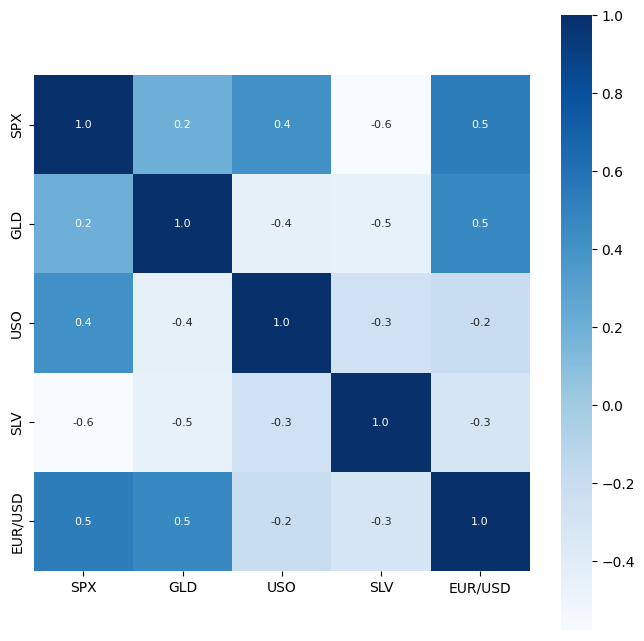

In [ ]:
correlation = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap="Blues")

In [ ]:
print(correlation['GLD'])

SPX        0.203396
GLD        1.000000
USO       -0.438832
SLV       -0.453430
EUR/USD    0.465239
Name: GLD, dtype: float64


/tmp/ipykernel_7225/3736964373.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

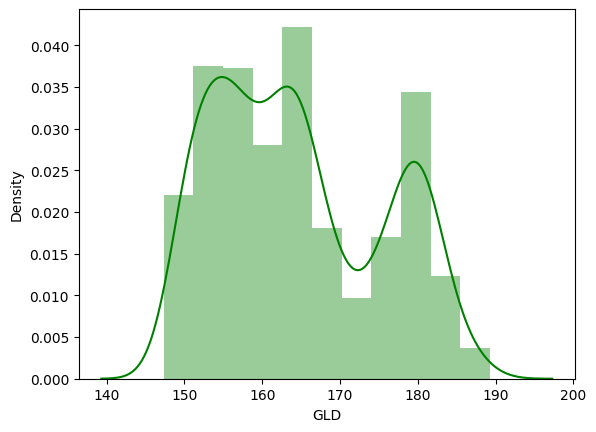

In [ ]:
sns.distplot(df['GLD'],color='green')

In [ ]:
X=df.drop(['Date','GLD'],axis=1)
Y=df['GLD']

In [ ]:
print(X)

         SPX    USO    SLV  EUR/USD
0    3706.97  39.33  21.67   1.2047
1    3715.81  38.09  21.57   1.1953
2    3701.74  36.67  21.21   1.1983
3    3703.99  36.93  21.58   1.1885
4    3719.28  36.45  21.17   1.1976
..       ...    ...    ...      ...
995  4072.97  61.69  13.82   1.1068
996  4082.70  61.77  13.85   1.1107
997  4088.30  62.46  14.00   1.1204
998  4087.48  63.76  14.59   1.1162
999  4092.93  63.83  15.18   1.1133

[1000 rows x 4 columns]


In [ ]:
print(Y)

0      168.10
1      169.67
2      169.69
3      168.57
4      169.36
        ...  
995    156.55
996    155.65
997    154.08
998    154.84
999    154.10
Name: GLD, Length: 1000, dtype: float64


In [ ]:
X_train,X_test, Y_train,Y_test= train_test_split(X,Y,test_size=0.2, random_state=2)

In [ ]:
regressor=RandomForestRegressor(n_estimators=100)
regressor.fit(X_train,Y_train)

RandomForestRegressor()

In [ ]:
test_data=regressor.predict(X_test)
print(test_data)

[163.3217 168.5714 156.4898 151.2112 155.2031 173.2261 173.579  151.8008
 158.3301 153.1822 153.6383 152.6193 178.257  158.8914 155.1356 178.89
 168.9204 171.1005 171.6317 162.8439 158.675  162.6299 157.2916 154.6838
 161.8175 179.5912 170.4724 165.7001 161.3803 171.7595 177.622  155.3513
 157.1453 167.4685 178.4536 160.769  166.5293 160.3716 181.3395 177.0756
 175.868  157.9424 154.6475 180.9086 182.2544 164.5338 186.1587 157.8342
 150.3498 163.9439 166.6183 163.753  178.2642 151.3586 155.4352 155.8521
 181.2903 180.1278 162.1666 156.479  161.8518 153.1389 155.6372 181.2746
 163.3173 160.9548 181.8507 181.1912 153.1879 153.4391 154.5904 150.6067
 150.9297 159.6981 153.4428 177.53   168.2178 157.5677 163.7793 182.5664
 166.6534 158.1989 154.0391 165.1054 150.0179 155.3442 159.9484 185.5882
 161.9315 162.8785 160.0602 152.6983 155.6905 167.4623 176.9078 165.0768
 167.7663 158.9084 156.2305 180.9546 173.3318 150.7882 151.8666 162.0154
 181.117  159.3452 179.0641 180.1599 181.5489 177.216

In [ ]:
error_score=metrics.r2_score(Y_test,test_data)
print(error_score*100)

90.15021851625077


In [ ]:
Y_test=list(Y_test)

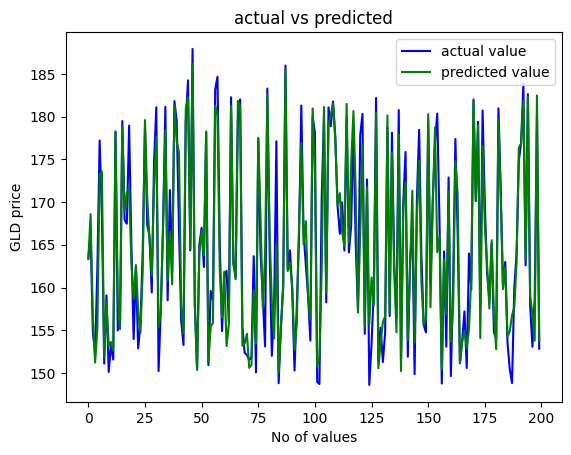

In [ ]:
plt.plot(Y_test,color='blue',label='actual value')
plt.plot(test_data,color='green',label='predicted value')
plt.title('actual vs predicted')
plt.xlabel('No of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()